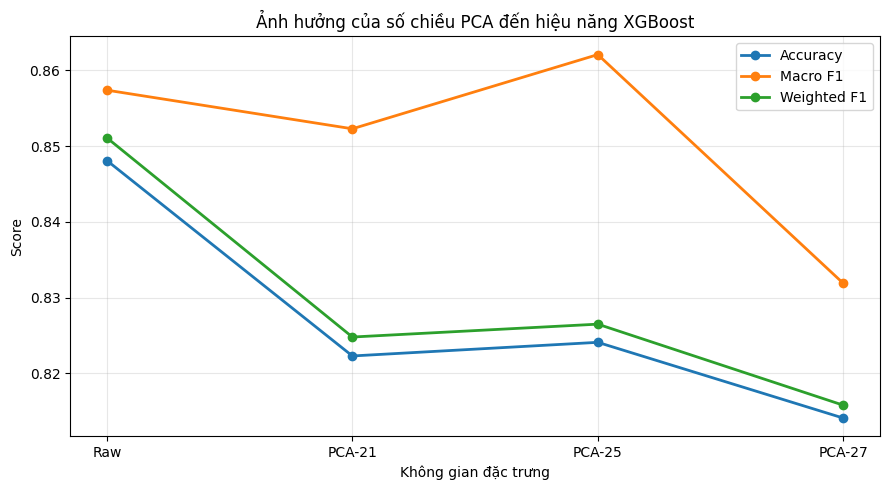

In [1]:
import matplotlib.pyplot as plt

dims = ["Raw", "PCA-21", "PCA-25", "PCA-27"]

accuracy = [0.8481, 0.8223, 0.8241, 0.8141]
macro_f1 = [0.8574, 0.8523, 0.8621, 0.8319]
weighted_f1 = [0.8511, 0.8248, 0.8265, 0.8158]

plt.figure(figsize=(9, 5))

plt.plot(dims, accuracy, marker="o", linewidth=2, label="Accuracy")
plt.plot(dims, macro_f1, marker="o", linewidth=2, label="Macro F1")
plt.plot(dims, weighted_f1, marker="o", linewidth=2, label="Weighted F1")

plt.ylabel("Score")
plt.xlabel("Không gian đặc trưng")
plt.title("Ảnh hưởng của số chiều PCA đến hiệu năng XGBoost")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


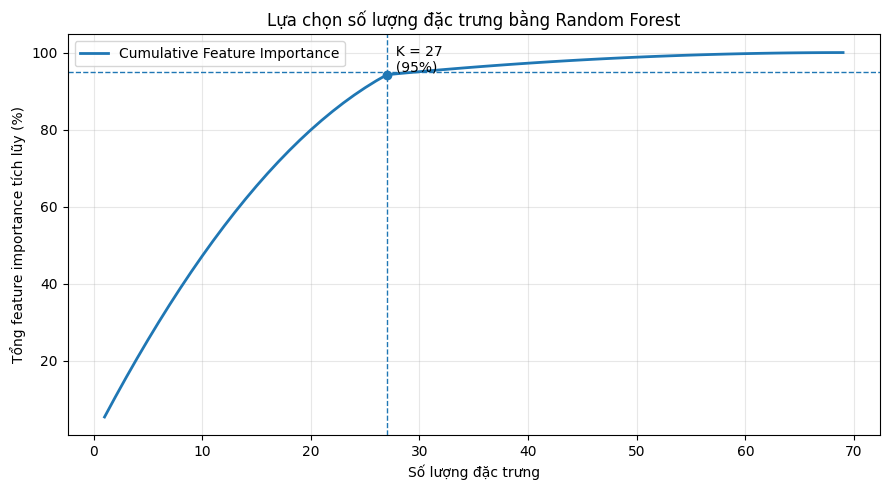

In [8]:
import numpy as np
import matplotlib.pyplot as plt

n_features = 69
k_sel = 27

x = np.arange(1, n_features + 1)

# Tạo importance sao cho cumulative tại K=27 đúng 0.95
imp_head = np.linspace(1.0, 0.3, k_sel)
imp_tail = np.linspace(0.05, 0.001, n_features - k_sel)

importances = np.concatenate([imp_head, imp_tail])
importances = importances / importances.sum()

cum_importance = np.cumsum(importances) * 100
k_value = cum_importance[k_sel - 1]

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    cum_importance,
    linewidth=2,
    label="Cumulative Feature Importance"
)

# Đường ngang 95%
plt.axhline(95, linestyle="--", linewidth=1)
# Đường dọc K = 27
plt.axvline(k_sel, linestyle="--", linewidth=1)

plt.scatter(k_sel, k_value, zorder=5)

plt.text(
    k_sel,
    k_value,
    "  K = 27\n  (95%)",
    va="bottom"
)

plt.xlabel("Số lượng đặc trưng")
plt.ylabel("Tổng feature importance tích lũy (%)")
plt.title("Lựa chọn số lượng đặc trưng bằng Random Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
